# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, plot_confusion_matrix
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras.models import Sequential


import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Data Preprocessing

In [2]:
df_train = pd.read_csv('/kaggle/input/mobile-price-classification/train.csv')
df_test = pd.read_csv('/kaggle/input/mobile-price-classification/test.csv')

In [3]:
df_train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df_train.shape

(2000, 21)

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [7]:
df_train['price_range'].unique()

array([1, 2, 3, 0])

In [8]:
df_train['price_range'].value_counts()

1    500
2    500
3    500
0    500
Name: price_range, dtype: int64

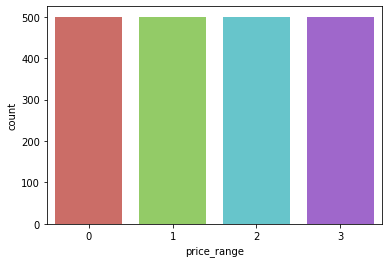

In [9]:
sns.countplot(x = 'price_range',data=df_train,palette = 'hls')
plt.show()

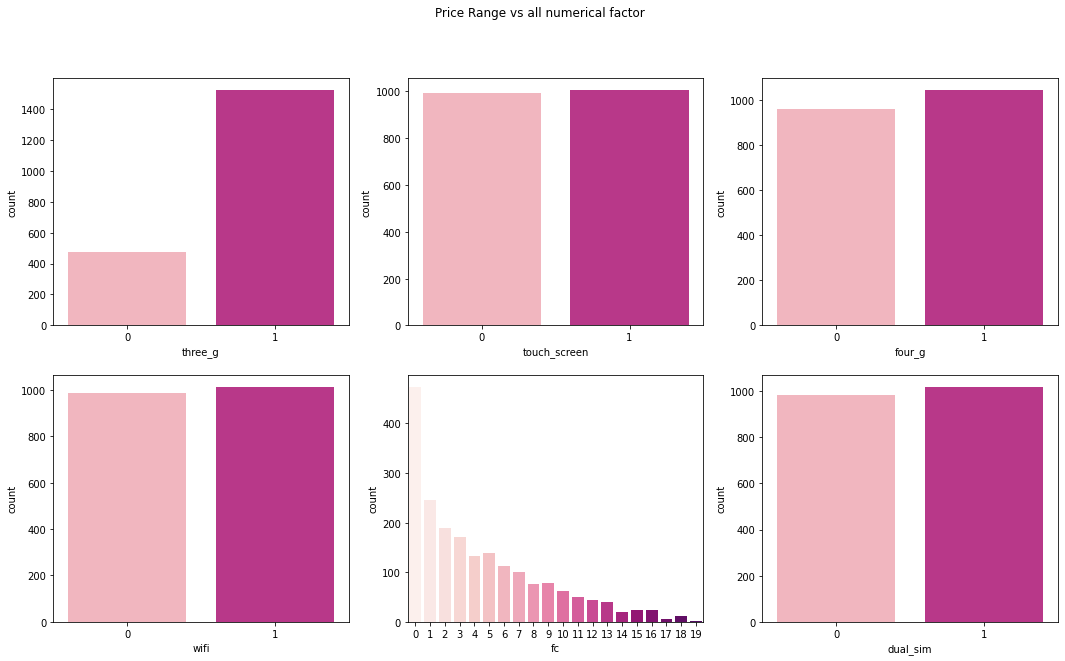

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Price Range vs all numerical factor')
sns.countplot(ax=axes[0, 0], data=df_train, x='three_g',palette='RdPu')
sns.countplot(ax=axes[0, 1], data=df_train, x='touch_screen',palette='RdPu')
sns.countplot(ax=axes[0, 2], data=df_train, x='four_g',palette='RdPu')
sns.countplot(ax=axes[1, 0], data=df_train, x='wifi',palette='RdPu')
sns.countplot(ax=axes[1,1],data = df_train, x ='fc' ,palette='RdPu')
sns.countplot(ax=axes[1,2],data = df_train, x ='dual_sim',palette='RdPu' )
plt.show()

<AxesSubplot:>

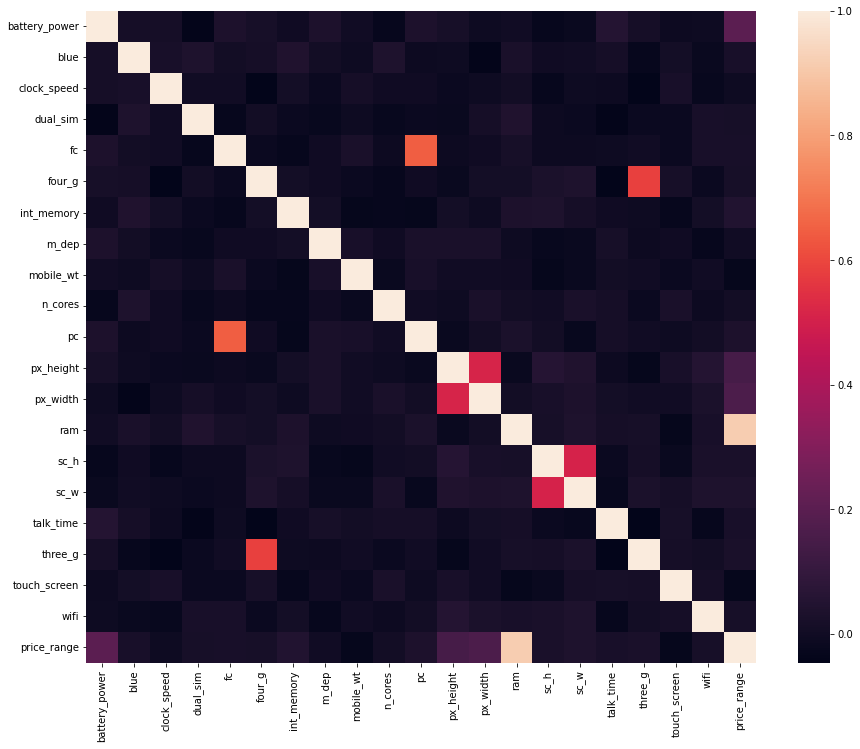

In [11]:
fig = plt.figure(figsize=(15,12))
sns.heatmap(df_train.corr())

In [12]:
print(f"Number of duplicate rows: {df_train.duplicated().sum()}")

Number of duplicate rows: 0


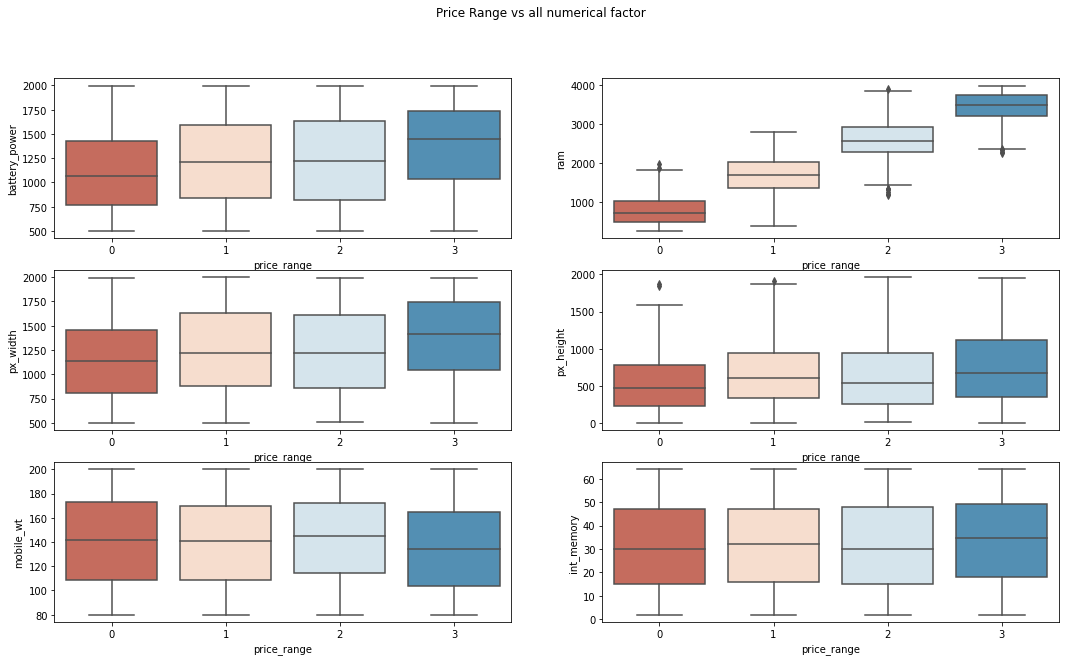

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

fig.suptitle('Price Range vs all numerical factor')

sns.boxplot(ax=axes[0, 0], data=df_train, x='price_range', y='battery_power',palette = "RdBu")
sns.boxplot(ax=axes[0, 1], data=df_train, x='price_range', y='ram',palette = "RdBu")
sns.boxplot(ax=axes[1, 0], data=df_train, x='price_range', y='px_width',palette = "RdBu")
sns.boxplot(ax=axes[1, 1], data=df_train, x='price_range', y='px_height',palette = "RdBu")
sns.boxplot(ax=axes[2, 0],data=df_train,x='price_range',y='mobile_wt',palette = "RdBu")
sns.boxplot(ax=axes[2, 1],data=df_train,x='price_range',y='int_memory',palette = "RdBu")
plt.show()


In [14]:
# convert to numpy arrays and split features from labels
x = df_train.drop('price_range', axis=1).values
x_predict = df_test.drop('id', axis=1).values
y = df_train['price_range'].values

In [15]:
# Scale the data using StandardScaler
sc = StandardScaler()
x = sc.fit_transform(x)
x_predict = sc.fit_transform(x_predict)

In [16]:
# OneHot Encoding for labels  
ohe = OneHotEncoder()
y= ohe.fit_transform(y.reshape(-1, 1)).toarray()

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

# Modeling

In [18]:
model = Sequential()

model.add(Dense(64, input_shape=(20,), activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(4, activation='softmax'))



In [19]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [20]:
history = model.fit(x_train, y_train,
batch_size=16,
epochs=500,
verbose=1,
validation_split = 0.2,
callbacks = [EarlyStopping(monitor = 'val_loss',patience = 80)]
)

Epoch 1/500
80/80 [==============================] - 1s 8ms/step - loss: 1.5398 - accuracy: 0.2469 - val_loss: 1.3782 - val_accuracy: 0.3000
Epoch 2/500
80/80 [==============================] - 0s 3ms/step - loss: 1.4057 - accuracy: 0.2570 - val_loss: 1.3769 - val_accuracy: 0.2688
Epoch 3/500
80/80 [==============================] - 0s 3ms/step - loss: 1.3971 - accuracy: 0.2844 - val_loss: 1.3722 - val_accuracy: 0.3313
Epoch 4/500
80/80 [==============================] - 0s 3ms/step - loss: 1.3848 - accuracy: 0.2922 - val_loss: 1.3559 - val_accuracy: 0.3969
Epoch 5/500
80/80 [==============================] - 0s 3ms/step - loss: 1.3504 - accuracy: 0.3063 - val_loss: 1.3105 - val_accuracy: 0.5219
Epoch 6/500
80/80 [==============================] - 0s 3ms/step - loss: 1.3081 - accuracy: 0.3555 - val_loss: 1.2393 - val_accuracy: 0.5844
Epoch 7/500
80/80 [==============================] - 0s 3ms/step - loss: 1.2540 - accuracy: 0.4094 - val_loss: 1.1211 - val_accuracy: 0.5781
Epoch 8/500
8

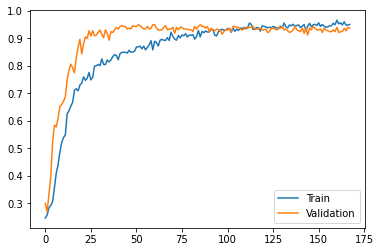

In [21]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])

plt.show()

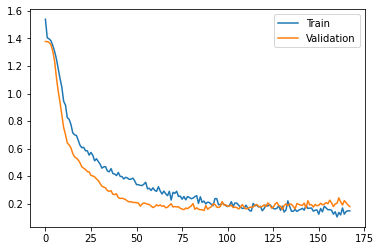

In [22]:
# Loss
plt.plot(history.history['loss']) 
plt.plot(history.history['val_loss']) 

plt.legend(['Train', 'Validation']) 


In [23]:
y_predict = model.predict(x_test)

predictions = list()
for i in range(len(y_predict)):
    predictions.append(np.argmax(y_predict[i]))

test = list()
for i in range(len(y_test)):
    test.append(np.argmax(y_test[i]))

In [24]:
print(classification_report(test, predictions))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       105
           1       0.95      0.96      0.95        95
           2       0.91      0.96      0.94        98
           3       0.99      0.93      0.96       102

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



# The End

### Thank you :)